# 02 - Clustering

This notebook investigates whether tracks and genres naturally form groups based only on acoustic features. The goal is to move from descriptive analytics into unsupervised learning.

## 1. Environment Setup

This block imports clustering and dimensionality reduction tools. PCA will help reduce many audio features into two dimensions for visualization, while KMeans will be used to create groups of similar tracks.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from src.preprocessing import MODEL_FEATURES, clean_tracks, load_tracks, scale_features

sns.set_theme(style="whitegrid")

## 2. Load, Clean, and Scale Features

Clustering algorithms are sensitive to feature scale. For example, `duration_ms` and `tempo` use much larger numeric ranges than `danceability` or `energy`. Standardizing the features prevents large-scale variables from dominating the distance calculations.

In [2]:
tracks = clean_tracks(load_tracks(PROJECT_ROOT / "data" / "raw" / "dataset.csv"))
scaled, scaler = scale_features(tracks, MODEL_FEATURES)

scaled.head()

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.024289,-0.305932,0.628394,-0.721328,0.298800,0.551483,-0.849230,-0.503538,0.758094,0.928984,-1.142994
1,-0.737425,-0.305932,-0.847891,-1.896382,-1.794228,-0.079182,1.837684,-0.503524,-0.591264,-0.799395,-1.490909
2,-0.162155,-0.305932,-0.744089,-1.127618,-0.297440,-0.273960,-0.313535,-0.503542,-0.507257,-1.366520,-1.529510
3,-0.245726,-0.305932,-1.735968,-2.320198,-2.049645,-0.457392,1.780439,-0.503313,-0.428501,-1.277786,1.987275
4,-0.274670,-0.305932,0.293923,-0.793026,-0.286864,-0.303272,0.466809,-0.503542,-0.686296,-1.185194,-0.074292


## 3. PCA Projection

PCA reduces the standardized audio features into two components. The important interpretation is that each axis is not one original feature; each axis is a weighted combination of all selected features.

`PCA Component 1` captures the strongest pattern of variation in the audio features. `PCA Component 2` captures the second strongest pattern, while being mathematically independent from the first.

In [3]:
pca = PCA(n_components=2, random_state=42)
embedding = pca.fit_transform(scaled)

pca_tracks = tracks[["track_name", "artists", "track_genre"]].copy()
pca_tracks["pca_1"] = embedding[:, 0]
pca_tracks["pca_2"] = embedding[:, 1]

explained_variance = pd.DataFrame(
    {
        "component": ["PCA 1", "PCA 2"],
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }
)

explained_variance

,component,explained_variance_ratio
0,PCA 1,0.263458
1,PCA 2,0.140211


## 4. What Each PCA Axis Is Consolidating

The table below shows the loading of each original feature on each PCA component. Larger absolute values mean the feature contributes more to that axis. Positive and negative signs indicate direction, not quality.

In [4]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=MODEL_FEATURES,
    columns=["pca_1_loading", "pca_2_loading"],
)

pca_loadings.assign(
    pca_1_abs=lambda df: df["pca_1_loading"].abs(),
    pca_2_abs=lambda df: df["pca_2_loading"].abs(),
).sort_values("pca_1_abs", ascending=False)

,pca_1_loading,pca_2_loading,pca_1_abs,pca_2_abs
loudness,0.511461,-0.099513,0.511461,0.099513
energy,0.502786,-0.268986,0.502786,0.268986
acousticness,-0.432506,0.331350,0.432506,0.331350
valence,0.290708,0.429852,0.290708,0.429852
instrumentalness,-0.283457,-0.310154,0.283457,0.310154
danceability,0.247891,0.453826,0.247891,0.453826
tempo,0.183277,-0.254468,0.183277,0.254468
explicit,0.127994,0.197061,0.127994,0.197061
speechiness,0.119603,0.207271,0.119603,0.207271
liveness,0.087023,-0.085144,0.087023,0.085144


## 5. PCA Loading Visualization

This chart makes the PCA interpretation more visual. Features with longer bars have stronger influence on that component. This helps translate the abstract PCA axes into analytical language.

Based on the ploted visual, my personal interpretation goes like:

PCA 1 captures an intensity contrast: tracks with higher loudness and energy move in the positive direction, while more acoustic and instrumental tracks move in the negative direction.

PCA 2 captures a movement/emotional accessibility contrast: tracks with higher danceability, valence, speechiness, and explicitness move in the positive direction, while longer, more instrumental, faster, and more energy-driven tracks move in the negative direction.

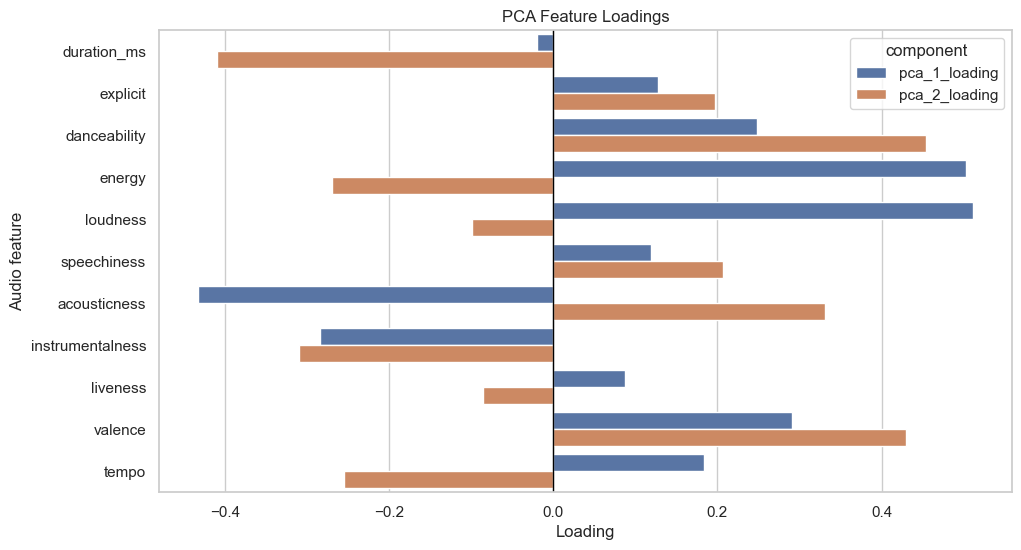

In [5]:
loading_plot = (
    pca_loadings.reset_index(names="feature")
    .melt(id_vars="feature", var_name="component", value_name="loading")
)

plt.figure(figsize=(11, 6))
sns.barplot(data=loading_plot, x="loading", y="feature", hue="component")
plt.axvline(0, color="black", linewidth=1)
plt.title("PCA Feature Loadings")
plt.xlabel("Loading")
plt.ylabel("Audio feature")
plt.show()

## 6. KMeans Clustering

KMeans assigns each track to a cluster based on audio similarity. The number of clusters can be tuned later, but starting with a small number makes the first interpretation easier.

In [6]:
kmeans = KMeans(n_clusters=8, random_state=42, n_init="auto")
pca_tracks["cluster"] = kmeans.fit_predict(scaled)

pca_tracks[["track_name", "artists", "track_genre", "cluster"]].head()

,track_name,artists,track_genre,cluster
0,Comedy,Gen Hoshino,acoustic,3
1,Ghost - Acoustic,Ben Woodward,acoustic,6
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,6
3,Can't Help Falling In Love,Kina Grannis,acoustic,6
4,Hold On,Chord Overstreet,acoustic,6


## 7. Track-Level Cluster Visualization

This chart shows individual tracks projected into PCA space and colored by cluster. It helps evaluate whether the algorithm found visible structure in the audio feature space.

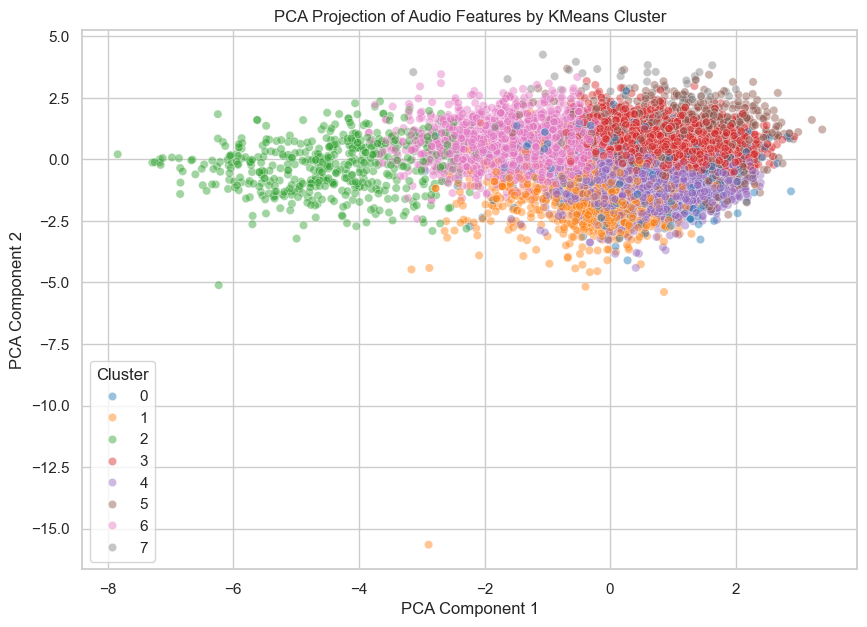

In [7]:
plot_sample = pca_tracks.sample(8000, random_state=42)

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_sample, x="pca_1", y="pca_2", hue="cluster", palette="tab10", alpha=0.45)
plt.title("PCA Projection of Audio Features by KMeans Cluster")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

## 8. Genre Position in PCA Space

To understand where each musical genre sits, we calculate the average PCA position for each genre. This creates a genre map: every point is one genre, positioned according to the average acoustic profile of its tracks.

The plot is interactive so all 114 genres can be explored with hover labels. To keep the visual readable, only a small set of reference genres is labeled directly on the chart.

In [9]:
genre_pca = (
    pca_tracks.groupby("track_genre", as_index=False)
    .agg(
        pca_1=("pca_1", "mean"),
        pca_2=("pca_2", "mean"),
        dominant_cluster=("cluster", lambda values: values.mode().iloc[0]),
    )
)

reference_genres = {
    "acoustic",
    "ambient",
    "black-metal",
    "brazil",
    "classical",
    "dance",
    "hip-hop",
    "jazz",
    "k-pop",
    "rock",
    "samba",
}
genre_pca["chart_label"] = genre_pca["track_genre"].where(
    genre_pca["track_genre"].isin(reference_genres), ""
)

fig = px.scatter(
    genre_pca,
    x="pca_1",
    y="pca_2",
    color="dominant_cluster",
    hover_name="track_genre",
    text="chart_label",
    title="Genre Map in PCA Space",
    labels={
        "pca_1": "PCA Component 1",
        "pca_2": "PCA Component 2",
        "dominant_cluster": "Dominant cluster",
    },
)

fig.update_traces(textposition="top center", textfont_size=8)
fig.update_layout(height=800, showlegend=True)
fig.show()

## 9. Reading the Genre Map

Genres that appear close together have similar average acoustic profiles according to the selected features. Genres far apart are more distinct in this compressed audio space.

The exact meaning of each direction should be interpreted together with the PCA loadings above. For example, if `energy`, `loudness`, and `acousticness` have strong loadings on PCA 1, then movement along PCA 1 likely reflects a contrast between intense/electric tracks and softer/acoustic tracks.

Based on my interpretation, this map suggests that PCA Component 1 separates more acoustic, softer, and less energetic genres from louder, more energetic, and production-intense genres. Classical and ambient appear on the far left, while dance, hip-hop, pop, and rock-oriented genres are positioned more to the right.

PCA Component 2 seems to capture a contrast between more danceable, positive, and speech/vocal-oriented genres at the top, and longer, more instrumental or sonically extreme genres at the bottom. Black-metal appears as a clear outlier in the lower region, indicating a distinctive average audio profile.